# EDA — NHANES 2015-2016 CBC_I

**Nguồn**: CDC/NCHS — National Health and Nutrition Examination Survey, public hoàn toàn, tải trực tiếp không cần đăng ký.

**File**: `Data/tabular/nhanes_cbc_2015/CBC_I_with_demographics.csv` — 9.165 dòng × 23 cột: CBC 5-dòng bạch cầu đầy đủ (% và số tuyệt đối) + RBC/HGB/HCT/MCV/MCH/MCHC/RDW/PLT/MPV + Age/Gender (join qua SEQN với DEMO_I).

Chất lượng cao nhất kho — dữ liệu khảo sát chính phủ.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['figure.figsize'] = (10, 5)
DATA = Path(r'D:\AI_08_V1\Data')

df = pd.read_csv(DATA / 'tabular' / 'nhanes_cbc_2015' / 'CBC_I_with_demographics.csv')
print('Shape:', df.shape)
print('Dòng trùng lặp:', df.duplicated().sum())
print('\nMissing values theo cột:')
print(df.isna().sum().sort_values(ascending=False))

Shape: (9165, 23)
Dòng trùng lặp: 0

Missing values theo cột:
LBXLYPCT    1049
LBXNEPCT    1049
LBXMOPCT    1049
LBXEOPCT    1049
LBXBAPCT    1049
LBDMONO     1049
LBDLYMNO    1049
LBDBANO     1049
LBDEONO     1049
LBDNENO     1049
LBXWBCSI    1048
LBXMCVSI    1048
LBXRBCSI    1048
LBXHGB      1048
LBXHCT      1048
LBXMPSI     1048
LBXMCHSI    1048
LBXRDW      1048
LBXPLTSI    1048
LBXMC       1018
SEQN           0
Age            0
Gender         0
dtype: int64


            mean    std    min     50%    max
LBXWBCSI    7.43   2.58   1.40    7.10  117.2
LBXRBCSI    4.75   0.47   2.52    4.72    7.9
LBXHGB     13.63   1.49   6.20   13.60   19.2
LBXHCT     40.94   4.18  21.80   40.70   59.1
LBXMCVSI   86.52   6.49  50.80   87.10  115.6
LBXRDW     13.73   1.26  11.50   13.40   26.4
LBXPLTSI  254.58  67.50  14.00  248.00  777.0
LBXMPSI     8.19   0.95   5.60    8.10   15.1


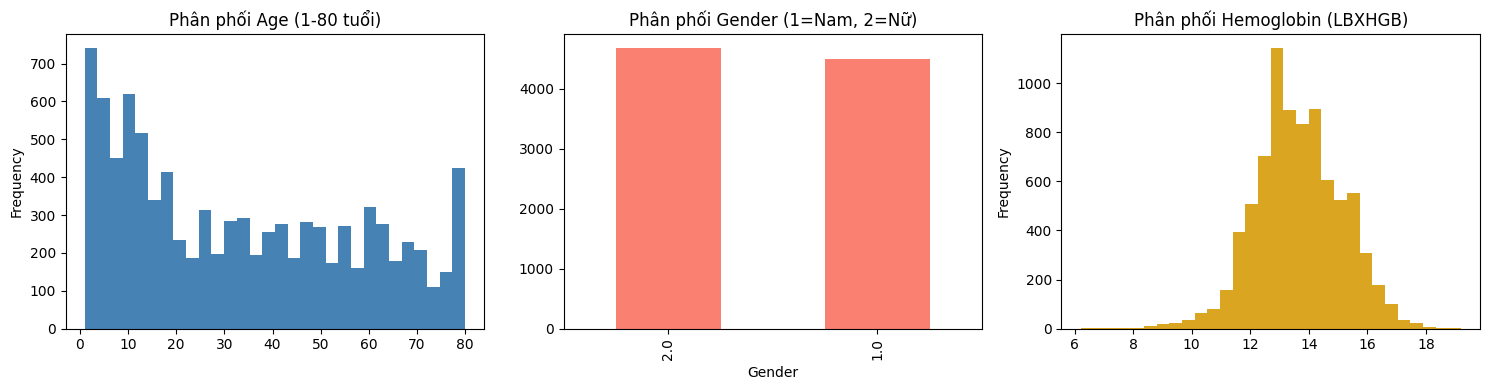

In [2]:
# Kiểm tra khoảng giá trị hợp lý (đối chiếu bộ CBC Test dataset #1 từng có giá trị âm/vô lý)
cbc_cols = ['LBXWBCSI', 'LBXRBCSI', 'LBXHGB', 'LBXHCT', 'LBXMCVSI', 'LBXRDW', 'LBXPLTSI', 'LBXMPSI']
print(df[cbc_cols].describe().T[['mean', 'std', 'min', '50%', 'max']].round(2))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df['Age'].plot.hist(ax=axes[0], bins=30, color='steelblue')
axes[0].set_title('Phân phối Age (1-80 tuổi)')
df['Gender'].value_counts().plot.bar(ax=axes[1], color='salmon')
axes[1].set_title('Phân phối Gender (1=Nam, 2=Nữ)')
df['LBXHGB'].plot.hist(ax=axes[2], bins=30, color='goldenrod')
axes[2].set_title('Phân phối Hemoglobin (LBXHGB)')
plt.tight_layout()
plt.show()

Tỷ lệ % trung bình mỗi dòng bạch cầu:
LBXLYPCT    34.15
LBXMOPCT     8.16
LBXNEPCT    53.96
LBXEOPCT     3.08
LBXBAPCT     0.78
dtype: float64
Tổng: 100.12 (kỳ vọng ~100%)


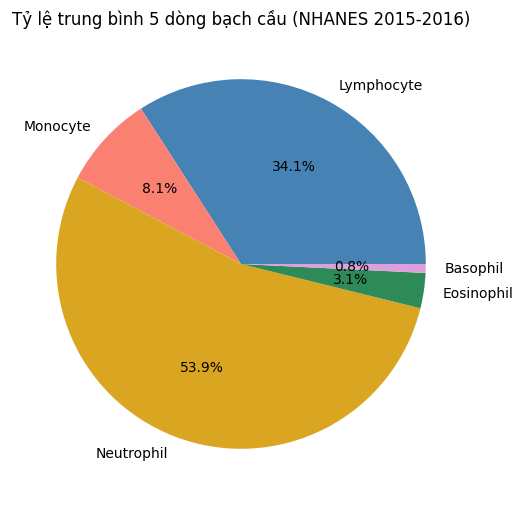

In [3]:
# Tỷ lệ 5 dòng bạch cầu trung bình (LYM/MO/NE/EO/BA %) — kiểm tra tổng ~100%
diff_cols = ['LBXLYPCT', 'LBXMOPCT', 'LBXNEPCT', 'LBXEOPCT', 'LBXBAPCT']
means = df[diff_cols].mean()
print('Tỷ lệ % trung bình mỗi dòng bạch cầu:')
print(means.round(2))
print('Tổng:', means.sum().round(2), '(kỳ vọng ~100%)')

means.plot.pie(autopct='%1.1f%%', figsize=(6, 6),
               labels=['Lymphocyte', 'Monocyte', 'Neutrophil', 'Eosinophil', 'Basophil'],
               colors=['steelblue', 'salmon', 'goldenrod', 'seagreen', 'plum'])
plt.title('Tỷ lệ trung bình 5 dòng bạch cầu (NHANES 2015-2016)')
plt.ylabel('')
plt.show()

## Nhận xét

- **Chất lượng cao nhất kho**: 0 dòng trùng lặp, không có giá trị âm/vô lý (khác hẳn CBC Test dataset #1 và Kaggle CBC vizeno #4), tổng % 5 dòng bạch cầu ≈ 100% như kỳ vọng — dữ liệu đáng tin cậy.
- 1.049/9.165 dòng thiếu phần 5-dòng bạch cầu chi tiết (còn 8.116 dòng đầy đủ hoàn toàn — khớp mô tả gốc "8.117 mẫu hoàn chỉnh").
- Age trải rộng 1–80 tuổi (bao phủ cả trẻ em), Gender cân bằng tốt (4.668 nữ / 4.497 nam).
- **Giới hạn quan trọng**: đây là dữ liệu khảo sát sức khỏe dân số, **không có nhãn chẩn đoán bệnh** — dùng làm nguồn "phân phối bình thường" chất lượng cao theo tuổi/giới (reference range), không dùng trực tiếp cho bài toán phân loại bệnh.